# Scientific Computing Report - EMAT 30008

Josh Beal - 2005289 - gx20774@bristol.ac.uk

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reportodes import solve_ode, RK4_step
from reportshooting import brusselator, brusspc, numshoot, plotorbit, hopf, hopfpc
from plot import plotsystemode, plotphaseportrait
from NumericalContinuation import natpar, plot_continuation
from BVP import solve_poisson, plot_poisson



## Software Demonstration

## Question 1

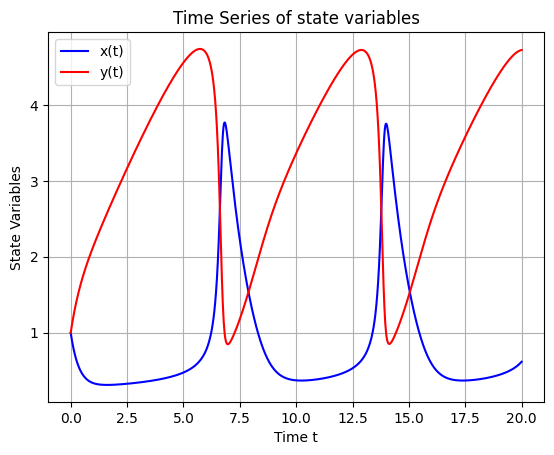

In [2]:
# 1a

# Parameters
f = brusselator
X0 = [1, 1]
t = np.linspace(0, 20, 1000)
method = 'RK4'
A = 1
B = 3

X = solve_ode(f, X0, t, method, A=A, B=B)

plotsystemode(X, t)


Shows going towards limit cycle as repeated behaviour. 

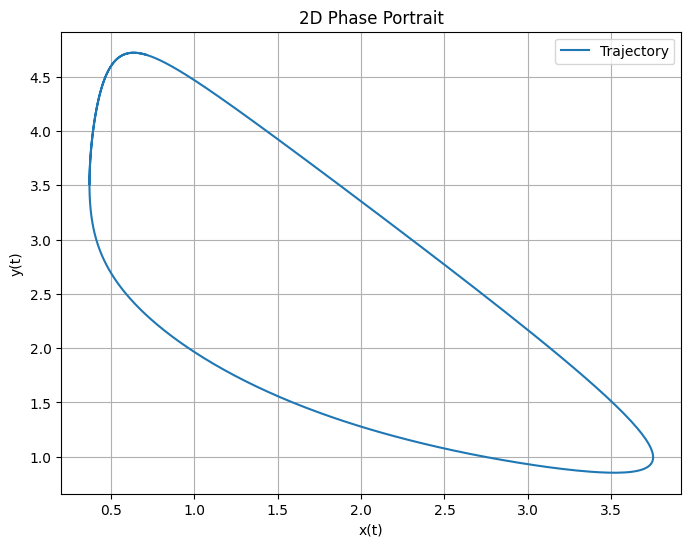

Optimized Initial Conditions: x(0) = 0.3706, y(0) = 3.5119
Optimized Period: T = 7.16


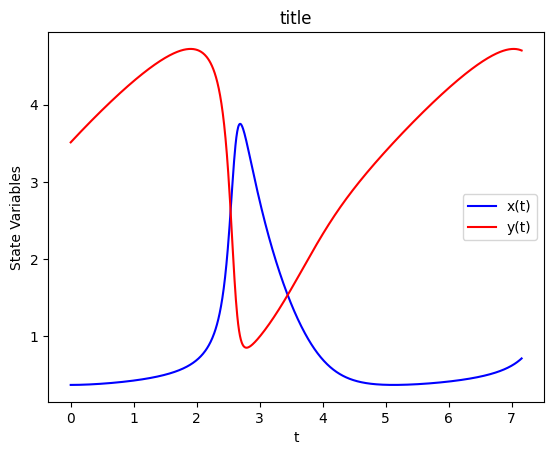

In [3]:
# 1b

f = brusselator
phasecondition = brusspc
X0 = [1, 1]
Tguess = 8
A = 1
B = 3

X0, T = numshoot(f, phasecondition, X0, Tguess, A=A, B=B)

x0, y0 = X0  
period = T
t = np.linspace(0, period, 1000)
X = solve_ode(f, X0, t, method, A=A, B=B)
plotphaseportrait(X)

print(f"Optimized Initial Conditions: x(0) = {x0:.4f}, y(0) = {y0:.4f}")
print(f"Optimized Period: T = {period:.2f}")
plotorbit(f, X0, T, A=A, B=B)

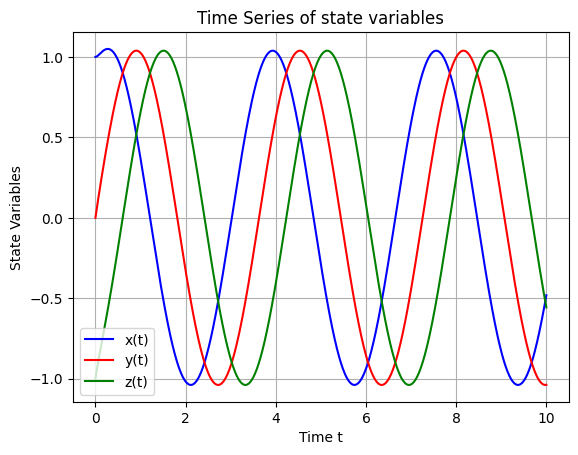

In [4]:
# 2a

f = hopf
X0 = [1, 0, -1]
t = np.linspace(0, 10, 1000)
method = 'RK4'
mu = 1

X = solve_ode(f, X0, t, method, mu=mu)

plotsystemode(X, t)

/Users/joshbeal/Library/Python/3.8/lib/python/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


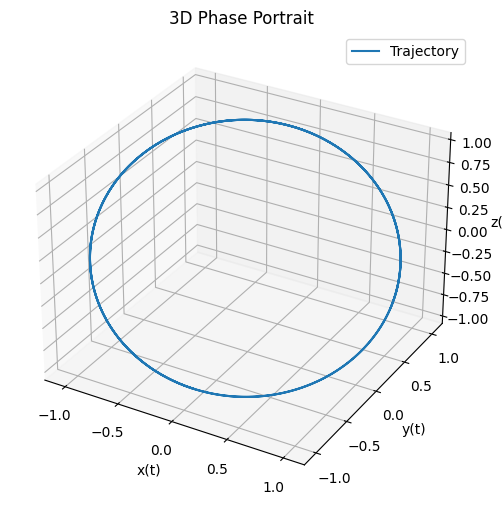

Optimized Initial Conditions: x(0) = 1.0333, y(0) = 0.5246 z(0) = -0.5246
Optimized Period: T = 3.63


In [5]:
# 2b

f = hopf
phasecondition = hopfpc
X0 = [1, 0, -1]
Tguess = 3
mu = 1

X0, T = numshoot(f, phasecondition, X0, Tguess, mu=mu)

x0, y0, z0 = X0  # Unpacking the optimized initial conditions
period = T
t = np.linspace(0, period, 1000)
X = solve_ode(f, X0, t, method, mu=mu)
plotphaseportrait(X)

print(f"Optimized Initial Conditions: x(0) = {x0:.4f}, y(0) = {y0:.4f}", f"z(0) = {z0:.4f}")
print(f"Optimized Period: T = {period:.2f}")
# T = 10
# plotorbit(f, X0, T, mu=mu)

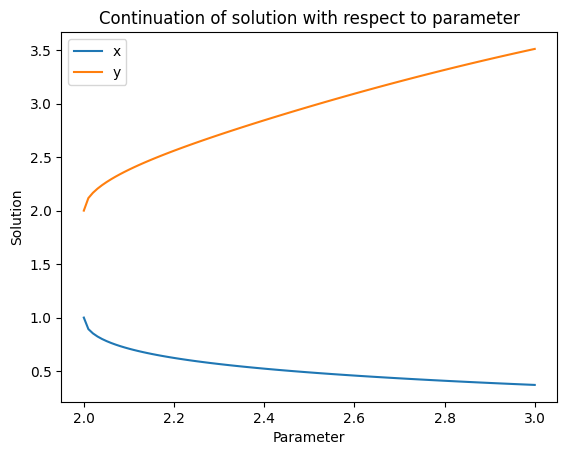

In [6]:
# 1c

f = brusselator
u0 = [0.37, 3.51]
parvalues = (3, 2, 100)
parameter = 'B'
Tguess = 6.5
phasecondition = brusspc
discretisation = 'shooting'
A = 1

u0, parvals, Ts = natpar(f, [u0], parvalues, parameter, Tguess, phasecondition, discretisation, A = A, B = B)
# print(parvals)
plot_continuation(u0, parvals)


Value of u at u(0) (for sigma=0.5) :-1.2432
Time to solve using dense method: 0.0002 seconds
Value of u at u(0) (for sigma=0.1) :-2.8377
Time to solve using sparse method: 0.0013 seconds


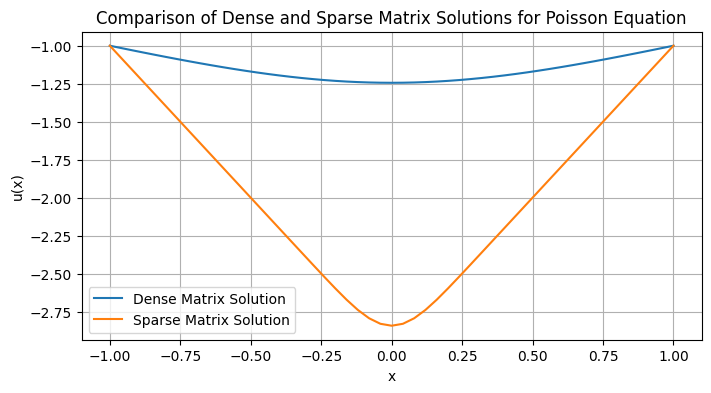

In [7]:
# 3a

lower_x = -1
upper_x = 1
num_points = 51
D = 1  # Diffusion
bc_left = -1  # Boundary condition at x = lower_x
bc_right = -1  # Boundary condition at x = upper_x

sigma = 0.5
xdense, udense, tdense = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'dense')
sigma = 0.1
xsparse, usparse, tsparse = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'sparse')

xlist = [xdense, xsparse]
ulist = [udense, usparse]
labels = ['Dense Matrix Solution', 'Sparse Matrix Solution']
title = 'Comparison of Dense and Sparse Matrix Solutions for Poisson Equation'
plot_poisson(xlist, ulist, labels, title)



Value of u at u(0) (for sigma=0.05) :-4.8304
Time to solve using dense method: 0.0095 seconds
Value of u at u(0) (for sigma=0.05) :-4.8304
Time to solve using sparse method: 0.0008 seconds


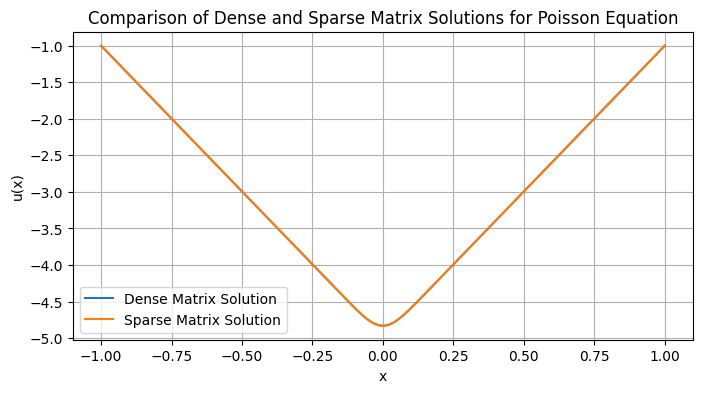

In [8]:
# 3b
lower_x = -1
upper_x = 1
num_points = 501
D = 1  # Diffusion
bc_left = -1  # Boundary condition at x = lower_x
bc_right = -1  # Boundary condition at x = upper_x

sigma = 0.05
xdense, udense, tdense = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'dense')
xsparse, usparse, tsparse = solve_poisson(lower_x, upper_x, num_points, D, sigma, bc_left, bc_right, 'sparse')

xlist = [xdense, xsparse]
ulist = [udense, usparse]
labels = ['Dense Matrix Solution', 'Sparse Matrix Solution']
title = 'Comparison of Dense and Sparse Matrix Solutions for Poisson Equation'
plot_poisson(xlist, ulist, labels, title)

jehbcih